In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import yfinance as yf

# Standard Kaggle Working Directory
RAW_DATA_DIR = Path("/kaggle/working/data/raw")
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

NIFTY50 = [
    "RELIANCE.NS",
    "TCS.NS",
    "HDFCBANK.NS",
    "INFY.NS",
    "HINDUNILVR.NS",
    "ICICIBANK.NS",
    "KOTAKBANK.NS",
    "BHARTIARTL.NS",
    "ITC.NS",
    "AXISBANK.NS",
    "SBIN.NS",
    "LT.NS",
    "BAJFINANCE.NS",
    "HCLTECH.NS",
    "ASIANPAINT.NS",
    "MARUTI.NS",
    "SUNPHARMA.NS",
    "TITAN.NS",
    "ULTRACEMCO.NS",
    "NESTLEIND.NS",
    "WIPRO.NS",
    "POWERGRID.NS",
    "NTPC.NS",
    "M&M.NS",
    "TECHM.NS",
    "TATAMOTORS.NS",
    "TATASTEEL.NS",
    "JSWSTEEL.NS",
    "BAJAJ-AUTO.NS",
    "CIPLA.NS",
    "DRREDDY.NS",
    "DIVISLAB.NS",
    "HEROMOTOCO.NS",
    "ONGC.NS",
    "COALINDIA.NS",
    "BPCL.NS",
    "GRASIM.NS",
    "ADANIPORTS.NS",
    "EICHERMOT.NS",
    "APOLLOHOSP.NS",
    "HINDALCO.NS",
    "TATACONSUM.NS",
    "BRITANNIA.NS",
    "SHREECEM.NS",
    "UPL.NS",
    "BAJAJFINSV.NS",
    "SBILIFE.NS",
    "HDFCLIFE.NS",
    "INDUSINDBK.NS",
    "LTIM.NS",
]

print("Downloading NIFTY 50 historical data...")
data = yf.download(
    NIFTY50,
    start="2010-01-01",
    end="2024-12-31",
    auto_adjust=True,
    threads=True,
)

close = data["Close"].ffill().bfill()
volume = data["Volume"].ffill().bfill()

close.to_csv(RAW_DATA_DIR / "nifty50_close.csv")
volume.to_csv(RAW_DATA_DIR / "nifty50_volume.csv")

print(
    f"Download Complete: {close.shape[0]} trading days x {close.shape[1]}"
    " stocks."
)

[*********************100%***********************]  50 of 50 completed

2 Failed downloads:
['TATAMOTORS.NS', 'LTIM.NS']: YFTzMissingError('possibly delisted; no timezone found')


Download Complete: 3700 trading days x 50 stocks.


In [5]:
def compute_log_returns(close_df: pd.DataFrame) -> pd.DataFrame:
    close_df = close_df.apply(pd.to_numeric, errors="coerce").ffill().bfill()
    returns = np.log(close_df / close_df.shift(1))
    return returns.fillna(0.0)


def label_regimes(
    returns_df: pd.DataFrame, vol_window: int = 20, crisis_pct: float = 85.0
) -> pd.Series:
    realized_vol = (
        returns_df.std(axis=1).rolling(vol_window, min_periods=1).mean()
    )
    rolling_5d = returns_df.rolling(5, min_periods=1).sum()
    drawdown_frac = (rolling_5d < -0.05).mean(axis=1)
    circuit_prox = (returns_df.abs() > 0.095).mean(axis=1)

    vol_q99 = realized_vol.quantile(0.99)
    vol_norm = (
        realized_vol / vol_q99
        if (not pd.isna(vol_q99) and vol_q99 > 0)
        else realized_vol
    )

    crisis_score = (
        0.5 * vol_norm + 0.3 * drawdown_frac + 0.2 * circuit_prox
    ).fillna(0.0)
    threshold = np.percentile(crisis_score, crisis_pct)
    return (crisis_score >= threshold).astype(int)


def make_windows(
    returns_df: pd.DataFrame, labels: pd.Series, T: int = 60
) -> tuple[np.ndarray, np.ndarray]:
    windows, window_labels = [], []
    arr, lab = returns_df.values, labels.values
    for i in range(T, len(arr)):
        windows.append(arr[i - T : i])
        window_labels.append(lab[i - 1])
    return np.array(windows, dtype=np.float32), np.array(
        window_labels, dtype=np.int64
    )


# Execute Preprocessing
close_df = pd.read_csv(
    RAW_DATA_DIR / "nifty50_close.csv", index_col=0, parse_dates=True
)
returns_df = compute_log_returns(close_df)
labels = label_regimes(returns_df, vol_window=20, crisis_pct=85.0)
windows, window_labels = make_windows(returns_df, labels, T=60)

np.save(RAW_DATA_DIR / "returns.npy", returns_df.values)
np.save(RAW_DATA_DIR / "regimes.npy", labels.values)
np.save(RAW_DATA_DIR / "windows.npy", windows)
np.save(RAW_DATA_DIR / "window_regimes.npy", window_labels)

print(
    f"Preprocessed: {returns_df.shape[0]} Days | Crisis Days:"
    f" {labels.sum()} ({labels.mean():.1%})"
)
print(f"Created 60-Day Windows Tensor: {windows.shape}")

Preprocessed: 3700 Days | Crisis Days: 555 (15.0%)
Created 60-Day Windows Tensor: (3640, 60, 50)


In [6]:
from concurrent.futures import ProcessPoolExecutor
import warnings
from statsmodels.tsa.stattools import grangercausalitytests

warnings.filterwarnings("ignore")

def process_single_window(
    window_data: tuple[int, np.ndarray], alpha: float = 0.5) -> tuple[int, np.ndarray]:
    idx, window = window_data
    N = window.shape[1]

    # Pearson Matrix
    corr = np.corrcoef(window, rowvar=False)
    corr = np.nan_to_num(corr, nan=0.0)
    A_pearson = np.where(np.abs(corr) >= 0.3, np.abs(corr), 0.0)
    np.fill_diagonal(A_pearson, 0.0)

    # Granger Matrix
    A_granger = np.zeros((N, N), dtype=np.float32)
    candidate_pairs = np.argwhere(np.abs(corr) >= 0.15)

    for i, j in candidate_pairs:
        if i == j:
            continue
        pair_data = window[:, [j, i]]
        if np.std(pair_data[:, 0]) < 1e-8 or np.std(pair_data[:, 1]) < 1e-8:
            continue
        try:
            res = grangercausalitytests(pair_data, maxlag=2, verbose=False)
            p_val = res[2][0]["ssr_ftest"][1]
            if p_val < 0.05:
                A_granger[i, j] = 1.0 - p_val
        except Exception:
            pass

    return idx, (alpha * A_pearson + (1.0 - alpha) * A_granger)


returns = np.load(RAW_DATA_DIR / "returns.npy")
T, stride = 60, 1
N_days, N_stocks = returns.shape
windows_data = [
    (i, returns[i : i + T]) for i in range(0, N_days - T + 1, stride)
]

num_workers = os.cpu_count()
print(f"Processing {len(windows_data)} windows using {num_workers} Kaggle CPU threads...")

results = [None] * len(windows_data)
completed = 0

with ProcessPoolExecutor(max_workers=num_workers) as executor:
    for idx, adj in executor.map(process_single_window, windows_data):
        results[idx] = adj
        completed += 1
        if completed % 500 == 0 or completed == len(windows_data):
            print(
                f"Progress: {completed}/{len(windows_data)} windows"
                f" ({completed / len(windows_data):.1%})")

adj_matrices = np.array(results, dtype=np.float32)
np.save(RAW_DATA_DIR / "adj_matrices.npy", adj_matrices)
print(f"Dynamic Graph Target Matrices Saved: {adj_matrices.shape}")

Processing 3641 windows using 4 Kaggle CPU threads...


KeyboardInterrupt: 

**GPU Version**

In [11]:
from pathlib import Path
from scipy.stats import f as f_dist
import time
import numpy as np
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing Graph Builder on GPU: {device}")

RAW_DATA_DIR = Path("/kaggle/working/data/raw")


def build_graphs_gpu(
    returns_tensor: torch.Tensor,
    T: int = 60,
    p: int = 2,
    alpha: float = 0.5,
    batch_size: int = 1000,
):
    """Batched GPU implementation of Pearson Correlation & Granger Causality tests."""
    N_days, N = returns_tensor.shape
    W = N_days - T + 1

    # Slide 60-day windows: shape [W, T, N]
    windows = returns_tensor.unfold(0, T, 1).permute(0, 2, 1).to(device)

    # 1. BATCHED PEARSON CORRELATION (GPU)
    mean = windows.mean(dim=1, keepdim=True)
    xc = windows - mean
    cov = torch.bmm(xc.transpose(1, 2), xc) / (T - 1)
    std = torch.sqrt(
        torch.diagonal(cov, dim1=1, dim2=2).clamp(min=1e-8)
    ).unsqueeze(-1)
    corr = cov / (std @ std.transpose(1, 2))
    corr = torch.nan_to_num(corr, nan=0.0)

    A_pearson = torch.where(corr.abs() >= 0.3, corr.abs(), 0.0)
    eye_N = torch.eye(N, device=device).bool()
    A_pearson[:, eye_N] = 0.0

    # 2. BATCHED GRANGER CAUSALITY (GPU)
    M = T - p
    df1, df2 = float(p), float(M - (2 * p + 1))

    Y = windows[:, p:, :].transpose(1, 2).unsqueeze(-1)

    ones = torch.ones((W, N, M, 1), device=device)
    lag1 = windows[:, p - 1 : T - 1, :].transpose(1, 2).unsqueeze(-1)
    lag2 = windows[:, p - 2 : T - 2, :].transpose(1, 2).unsqueeze(-1)
    Z = torch.cat([ones, lag1, lag2], dim=-1)

    Az = Z.transpose(-2, -1) @ Z + 1e-6 * torch.eye(3, device=device)
    bz = Z.transpose(-2, -1) @ Y
    theta_z = torch.linalg.solve(Az, bz)
    y_sq = (Y**2).sum(dim=-2)
    RSS_r = y_sq - (bz.transpose(-2, -1) @ theta_z).squeeze(-1)

    A_granger_list = []

    for start_idx in range(0, W, batch_size):
        end_idx = min(start_idx + batch_size, W)
        b_W = end_idx - start_idx

        b_Y = Y[start_idx:end_idx]
        b_Z = Z[start_idx:end_idx].unsqueeze(2).expand(b_W, N, N, M, 3)

        p_lag1 = (
            windows[start_idx:end_idx, p - 1 : T - 1, :]
            .transpose(1, 2)
            .unsqueeze(1)
            .unsqueeze(-1)
        )
        p_lag2 = (
            windows[start_idx:end_idx, p - 2 : T - 2, :]
            .transpose(1, 2)
            .unsqueeze(1)
            .unsqueeze(-1)
        )
        P = torch.cat([p_lag1, p_lag2], dim=-1).expand(b_W, N, N, M, 2)

        X = torch.cat([b_Z, P], dim=-1)

        Ax = X.transpose(-2, -1) @ X + 1e-6 * torch.eye(5, device=device)
        bx = X.transpose(-2, -1) @ b_Y.unsqueeze(2)
        theta_x = torch.linalg.solve(Ax, bx)

        b_y_sq = y_sq[start_idx:end_idx].unsqueeze(2).unsqueeze(-1)
        RSS_u = (b_y_sq - bx.transpose(-2, -1) @ theta_x).squeeze(-1).squeeze(-1)

        b_RSS_r = RSS_r[start_idx:end_idx].expand(b_W, N, N)
        F_stat = ((b_RSS_r - RSS_u) / df1) / (RSS_u / df2)
        F_stat = F_stat.clamp(min=0.0)

        # beta_x = df2 / (df2 + df1 * F_stat)
        # p_vals = torch.special.betainc(
        #     torch.tensor(df2 / 2.0, device=device),
        #     torch.tensor(df1 / 2.0, device=device),
        #     beta_x,
        # )
        p_vals = torch.from_numpy(f_dist.sf(F_stat.cpu().numpy(), df1, df2)).to(device).float()

        b_A_granger = torch.where(p_vals < 0.05, 1.0 - p_vals, 0.0)
        b_A_granger[:, eye_N] = 0.0
        A_granger_list.append(b_A_granger)

    A_granger = torch.cat(A_granger_list, dim=0)
    return alpha * A_pearson + (1.0 - alpha) * A_granger


# Load NumPy arrays cleanly into PyTorch Tensors
start_time = time.time()
returns_path = RAW_DATA_DIR / "returns.npy"

if not returns_path.exists():
    raise FileNotFoundError(
        f"Missing {returns_path}. Run Preprocessing (Cell 1 & 2) first!"
    )

returns_np = np.load(returns_path)
returns_tensor = torch.from_numpy(returns_np).float()

adj_matrices_gpu = build_graphs_gpu(
    returns_tensor, T=60, alpha=0.5, batch_size=1000
)

output_path = RAW_DATA_DIR / "adj_matrices.npy"
np.save(output_path, adj_matrices_gpu.cpu().numpy())

elapsed = time.time() - start_time
print(f"Finished in {elapsed:.2f} seconds!")
print(f"Saved graph tensor to {output_path}: {adj_matrices_gpu.shape}")

Executing Graph Builder on GPU: cuda
Finished in 3.38 seconds!
Saved graph tensor to /kaggle/working/data/raw/adj_matrices.npy: torch.Size([3641, 50, 50])


In [12]:
FILES = [
    "returns.npy",
    "regimes.npy",
    "windows.npy",
    "window_regimes.npy",
    "adj_matrices.npy",
]

print("KAGGLE WORKING DIR DATA VERIFICATION")
for fname in FILES:
    path = RAW_DATA_DIR / fname
    if path.exists():
        arr = np.load(path)
        print(
            f"{fname:<20} | Shape: {str(arr.shape):<18} | Type:"
            f" {arr.dtype}"
        )
    else:
        print(f"Missing: {fname}")

KAGGLE WORKING DIR DATA VERIFICATION
returns.npy          | Shape: (3700, 50)         | Type: float64
regimes.npy          | Shape: (3700,)            | Type: int64
windows.npy          | Shape: (3640, 60, 50)     | Type: float32
window_regimes.npy   | Shape: (3640,)            | Type: int64
adj_matrices.npy     | Shape: (3641, 50, 50)     | Type: float32


In [13]:
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpu_count = torch.cuda.device_count()
print(f"Training on Device: {device} | Active GPUs: {gpu_count}")

RAW_DATA_DIR = Path("/kaggle/working/data/raw")


# 2. PyTorch Dataset with Auto-Shape Alignment
class VortexGraphDataset(Dataset):

    def __init__(self, data_dir: Path):
        windows = np.load(data_dir / "windows.npy")  # [3640, 60, 50]
        adj = np.load(data_dir / "adj_matrices.npy")  # [3641, 50, 50]
        labels = np.load(data_dir / "window_regimes.npy")  # [3640]

        # Truncate adj_matrices to match 3640 windows precisely
        min_len = min(len(windows), len(adj), len(labels))
        windows = windows[:min_len]
        adj = adj[:min_len]
        labels = labels[:min_len]

        # Shape formatting: [Batch, Nodes=50, Features=60]
        self.x = torch.from_numpy(windows).permute(0, 2, 1).float()
        self.adj = torch.from_numpy(adj).float()
        self.y = torch.from_numpy(labels).long()

        print(
            f"Dataset Loaded: {len(self.y)} samples | Nodes: {self.x.shape[1]} |"
            f" Lookback T: {self.x.shape[2]}"
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.adj[idx], self.y[idx]


# 3. Dynamic Graph Attention Network (GAT) Layer
class GraphAttentionLayer(nn.Module):

    def __init__(
        self, in_features: int, out_features: int, dropout: float = 0.2
    ):
        super().__init__()
        self.W = nn.Linear(in_features, out_features, bias=False)
        self.a = nn.Linear(2 * out_features, 1, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.leaky_relu = nn.LeakyReLU(0.2)

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        # x: [B, N, in_features], adj: [B, N, N]
        B, N, _ = x.shape
        h = self.W(x)  # [B, N, out_features]

        # Calculate attention scores for all pairs (i, j)
        h_i = h.unsqueeze(2).expand(B, N, N, -1)
        h_j = h.unsqueeze(1).expand(B, N, N, -1)
        pair_h = torch.cat([h_i, h_j], dim=-1)  # [B, N, N, 2*out_features]

        e = self.leaky_relu(self.a(pair_h)).squeeze(-1)  # [B, N, N]

        # Mask non-existent edges using empirical graph topology
        zero_vec = -9e15 * torch.ones_like(e)
        attention = torch.where(adj > 0, e, zero_vec)
        attention = F.softmax(attention, dim=-1)
        attention = self.dropout(attention)

        h_prime = torch.bmm(attention, h)  # [B, N, out_features]
        return F.elu(h_prime)


# 4. Full Dynamic GAT Encoder Architecture
class DynamicGATEncoder(nn.Module):

    def __init__(
        self,
        in_dim: int = 60,
        hidden_dim: int = 64,
        out_dim: int = 32,
        num_classes: int = 2,
    ):
        super().__init__()
        self.gat1 = GraphAttentionLayer(in_dim, hidden_dim)
        self.gat2 = GraphAttentionLayer(hidden_dim, out_dim)

        # Graph Readout & Regime Classifier
        self.classifier = nn.Sequential(
            nn.Linear(out_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        h1 = self.gat1(x, adj)
        h2 = self.gat2(h1, adj)

        # Graph pooling: Mean + Max over nodes (stocks)
        mean_pool = h2.mean(dim=1)
        max_pool = h2.max(dim=1)[0]
        graph_emb = torch.cat([mean_pool, max_pool], dim=-1)  # [B, out_dim * 2]

        logits = self.classifier(graph_emb)
        return logits


# 5. Data Loaders & Chronological Split
full_dataset = VortexGraphDataset(RAW_DATA_DIR)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True, pin_memory=True, num_workers=2
)
val_loader = DataLoader(
    val_dataset, batch_size=64, shuffle=False, pin_memory=True, num_workers=2
)

# 6. Instantiate & Distribute across GPUs
model = DynamicGATEncoder(in_dim=60, hidden_dim=64, out_dim=32, num_classes=2)
if gpu_count > 1:
    print(f"Deploying model onto {gpu_count} GPUs via DataParallel")
    model = nn.DataParallel(model)

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler()

epochs = 20
print("STARTING DYNAMIC GAT ENCODER TRAINING")

for epoch in range(1, epochs + 1):
    model.train()
    train_loss, train_correct = 0.0, 0

    for x_b, adj_b, y_b in train_loader:
        x_b, adj_b, y_b = (
            x_b.to(device, non_blocking=True),
            adj_b.to(device, non_blocking=True),
            y_b.to(device, non_blocking=True),
        )

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            logits = model(x_b, adj_b)
            loss = criterion(logits, y_b)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * x_b.size(0)
        train_correct += (logits.argmax(dim=-1) == y_b).sum().item()

    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for x_b, adj_b, y_b in val_loader:
            x_b, adj_b, y_b = (
                x_b.to(device, non_blocking=True),
                adj_b.to(device, non_blocking=True),
                y_b.to(device, non_blocking=True),
            )
            with torch.cuda.amp.autocast():
                logits = model(x_b, adj_b)
                loss = criterion(logits, y_b)

            val_loss += loss.item() * x_b.size(0)
            val_correct += (logits.argmax(dim=-1) == y_b).sum().item()

    train_acc = train_correct / train_size
    val_acc = val_correct / val_size
    avg_train_loss = train_loss / train_size
    avg_val_loss = val_loss / val_size

    print(
        f"Epoch [{epoch:02d}/{epochs}] | Train Loss: {avg_train_loss:.4f} |"
        f" Train Acc: {train_acc:.2%} | Val Loss: {avg_val_loss:.4f} | Val"
        f" Acc: {val_acc:.2%}"
    )

torch.save(
    model.module.state_dict() if gpu_count > 1 else model.state_dict(),
    RAW_DATA_DIR.parent / "gat_encoder.pth",
)
print(f"Training Complete! Encoder saved to {RAW_DATA_DIR.parent}/gat_encoder.pth")

Training on Device: cuda | Active GPUs: 2
Dataset Loaded: 3640 samples | Nodes: 50 | Lookback T: 60
⚡ Deploying model onto 2 GPUs via DataParallel
STARTING DYNAMIC GAT ENCODER TRAINING
Epoch [01/20] | Train Loss: nan | Train Acc: 85.16% | Val Loss: nan | Val Acc: 85.99%
Epoch [02/20] | Train Loss: nan | Train Acc: 85.16% | Val Loss: nan | Val Acc: 85.99%
Epoch [03/20] | Train Loss: nan | Train Acc: 85.16% | Val Loss: nan | Val Acc: 85.99%
Epoch [04/20] | Train Loss: nan | Train Acc: 85.16% | Val Loss: nan | Val Acc: 85.99%
Epoch [05/20] | Train Loss: nan | Train Acc: 85.16% | Val Loss: nan | Val Acc: 85.99%
Epoch [06/20] | Train Loss: nan | Train Acc: 85.16% | Val Loss: nan | Val Acc: 85.99%
Epoch [07/20] | Train Loss: nan | Train Acc: 85.16% | Val Loss: nan | Val Acc: 85.99%
Epoch [08/20] | Train Loss: nan | Train Acc: 85.16% | Val Loss: nan | Val Acc: 85.99%
Epoch [09/20] | Train Loss: nan | Train Acc: 85.16% | Val Loss: nan | Val Acc: 85.99%
Epoch [10/20] | Train Loss: nan | Train A

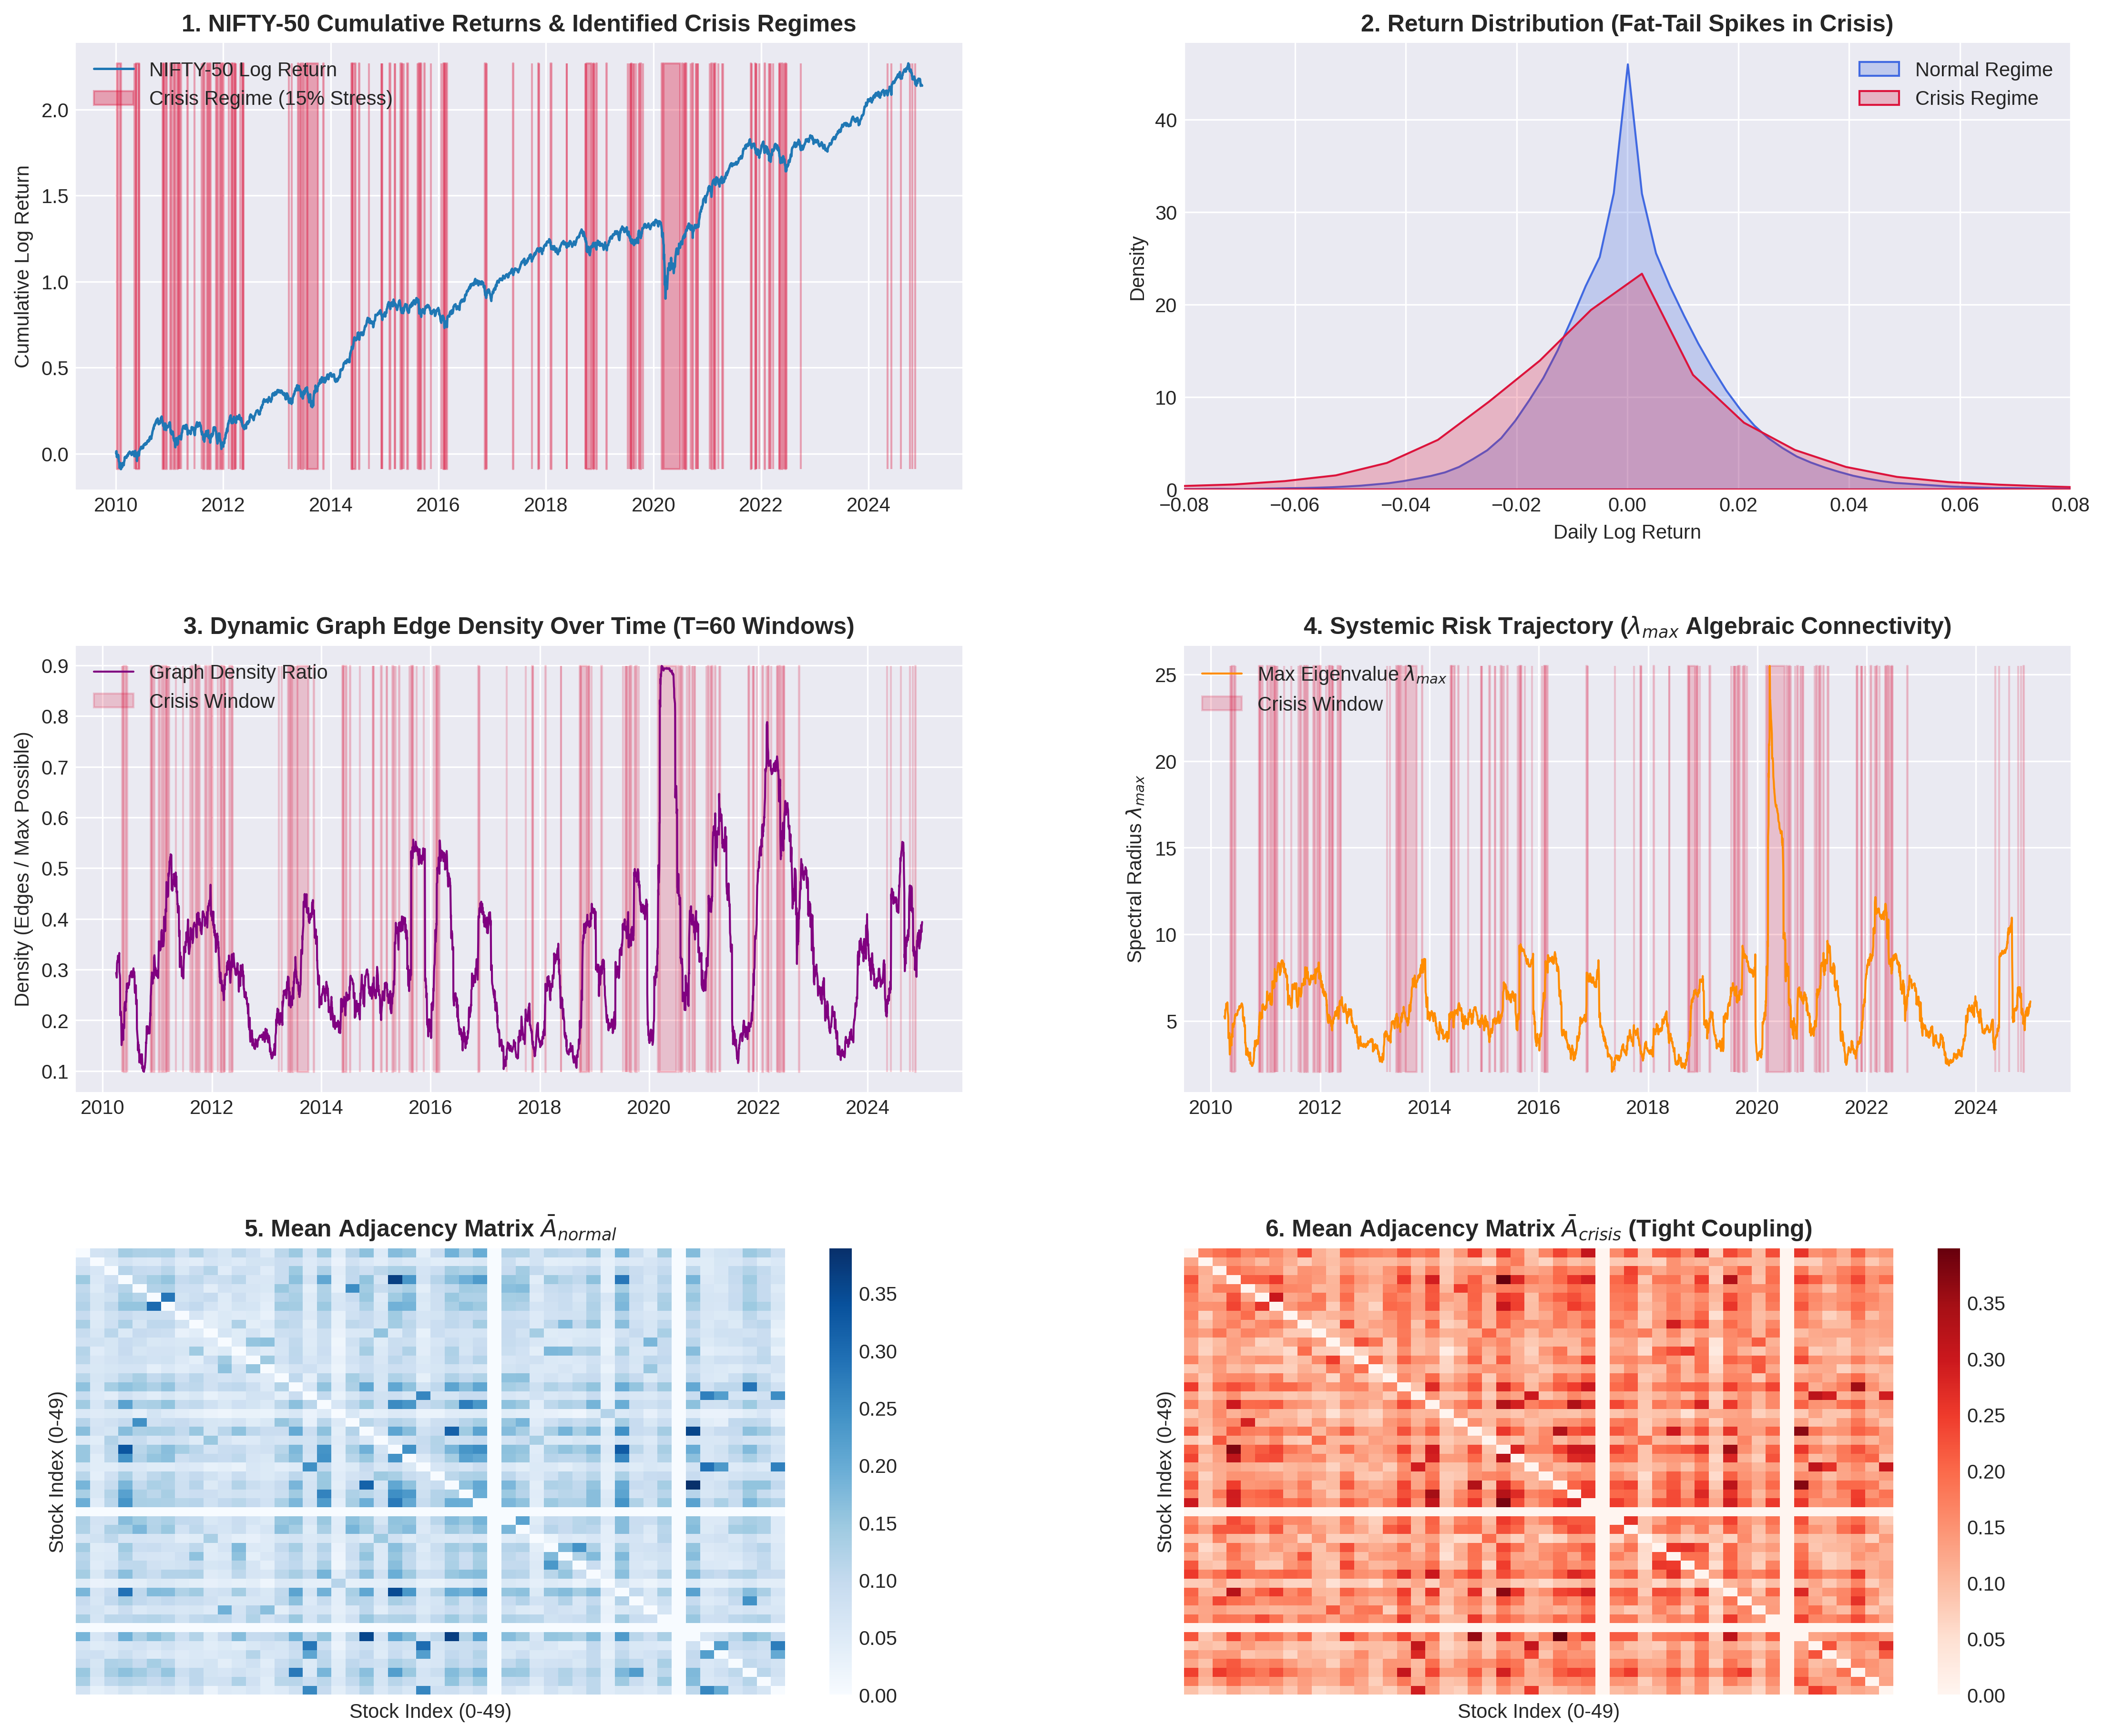

Saved Master EDA Dashboard to: /kaggle/working/plots/vortex_master_eda_dashboard.png


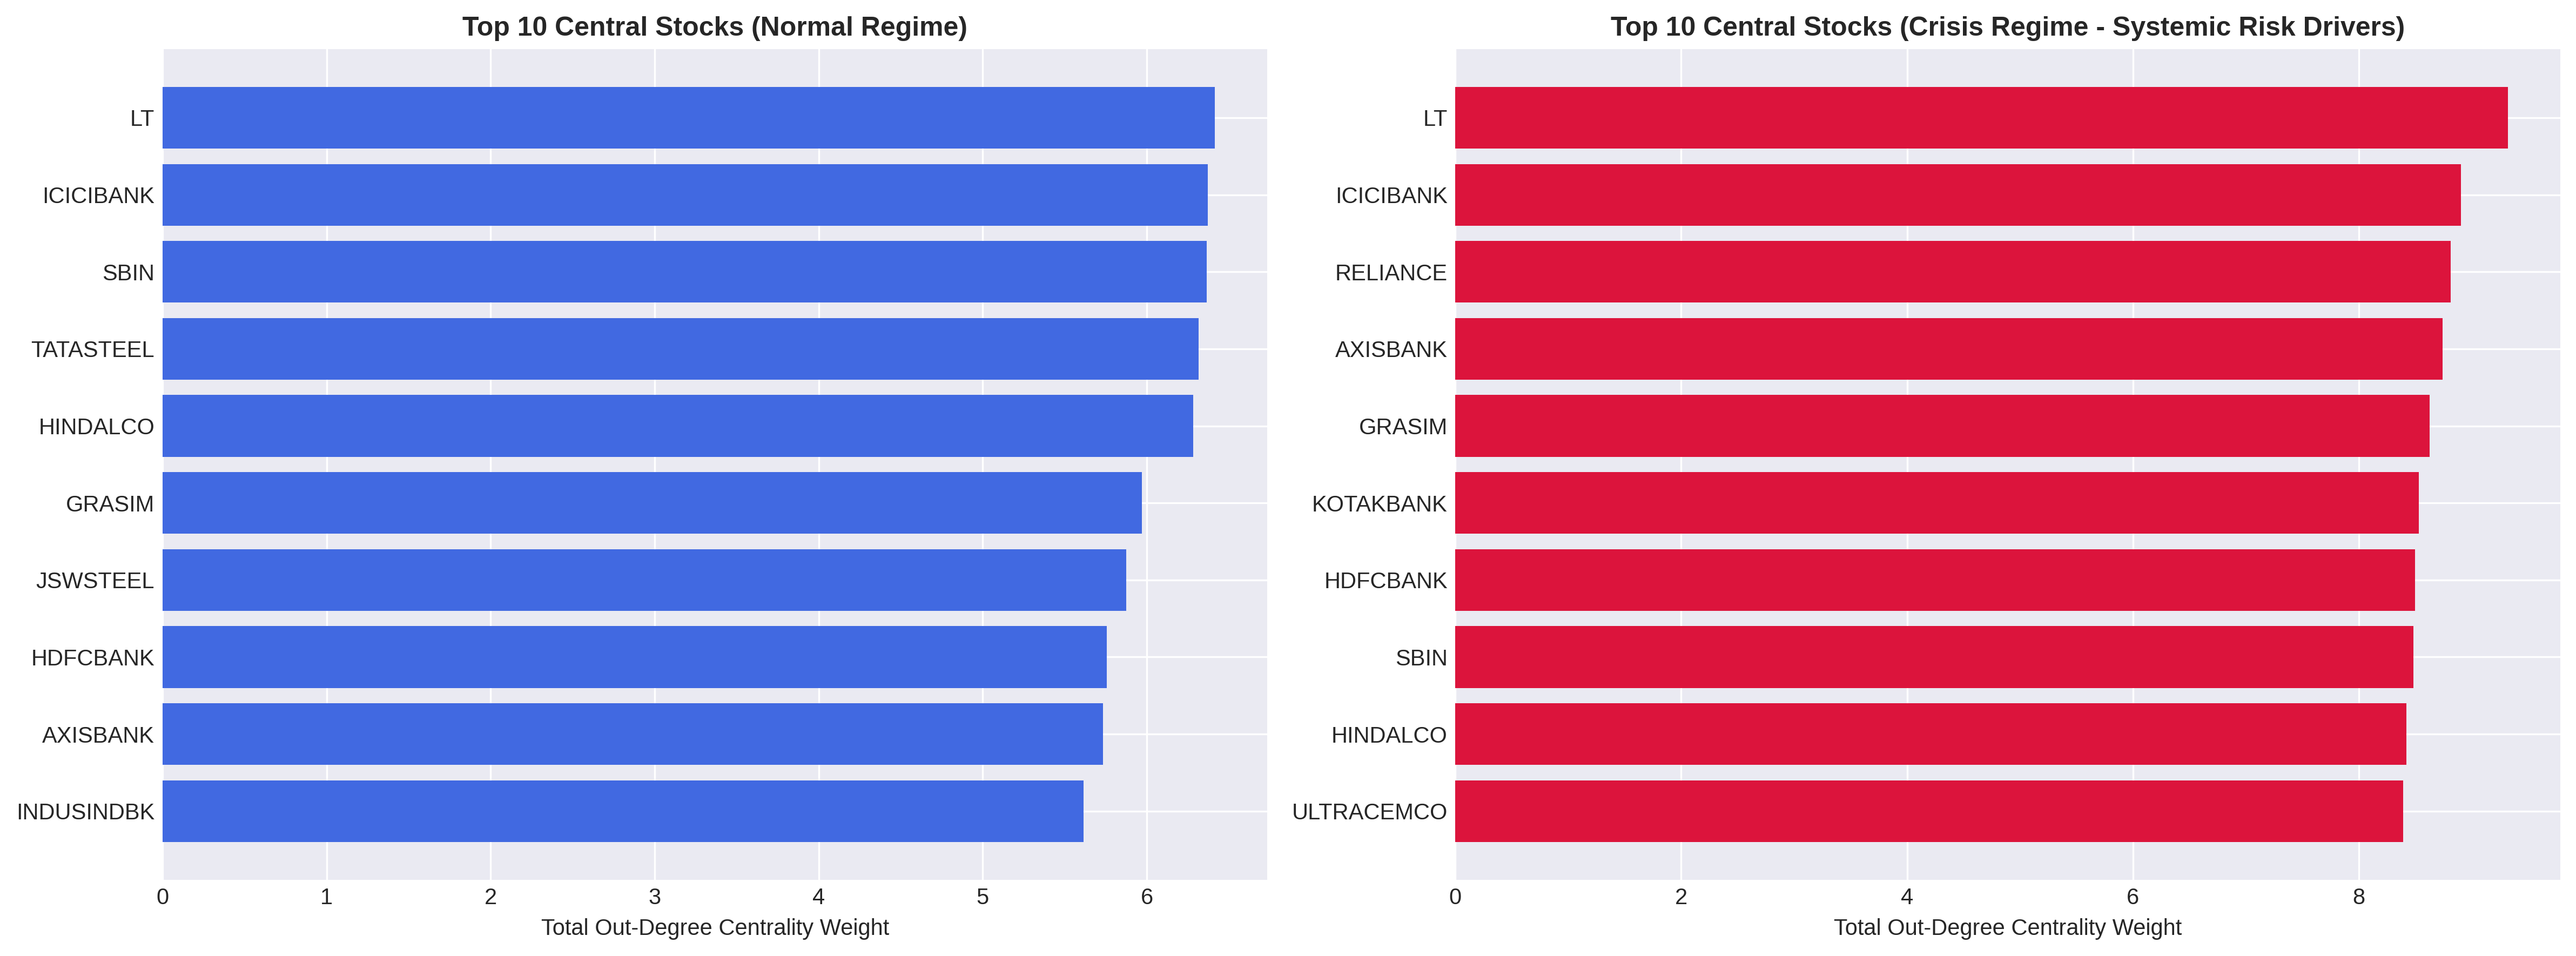

Saved Network Hub Analysis to: /kaggle/working/plots/vortex_network_hubs.png


In [15]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set path and output directory
RAW_DIR = Path("/kaggle/working/data/raw")
PLOT_DIR = Path("/kaggle/working/plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Set visual styling
plt.style.use(
    "seaborn-v0_8-darkgrid"
    if "seaborn-v0_8-darkgrid" in plt.style.available
    else "default"
)
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 10

# 1. Load Datasets & Align Lengths
returns = np.load(RAW_DIR / "returns.npy")  # [3700, 50]
regimes = np.load(RAW_DIR / "regimes.npy")  # [3700]
adj_matrices = np.load(RAW_DIR / "adj_matrices.npy")  # [3641, 50, 50]
window_regimes = np.load(RAW_DIR / "window_regimes.npy")  # [3640]

min_len = min(len(adj_matrices), len(window_regimes))
adj_matrices = adj_matrices[:min_len]  # Align to [3640, 50, 50]
window_regimes = window_regimes[:min_len]

# Load Stock Tickers (if CSV exists)
try:
    close_df = pd.read_csv(
        RAW_DIR / "nifty50_close.csv", index_col=0, parse_dates=True
    )
    tickers = [c.replace(".NS", "") for c in close_df.columns]
    dates = close_df.index[-len(returns):]
except Exception:
    tickers = [f"S{i:02d}" for i in range(50)]
    dates = np.arange(len(returns))

window_dates = dates[60 : 60 + min_len]

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# Panel 1: Cumulative Return & Crisis Shading Timeline
ax1 = axes[0, 0]
cum_returns = np.cumsum(returns.mean(axis=1))
ax1.plot(
    dates, cum_returns, color="#1f77b4", linewidth=1.2, label="NIFTY-50 Log Return"
)
ax1.fill_between(
    dates,
    cum_returns.min(),
    cum_returns.max(),
    where=(regimes[: len(dates)] == 1),
    color="crimson",
    alpha=0.35,
    label="Crisis Regime (15% Stress)",
)
ax1.set_title(
    "1. NIFTY-50 Cumulative Returns & Identified Crisis Regimes",
    fontweight="bold",
)
ax1.set_ylabel("Cumulative Log Return")
ax1.legend(loc="upper left")

# Panel 2: Return Density (Normal vs Crisis Regimes)
ax2 = axes[0, 1]
norm_ret = returns[regimes == 0].flatten()
cris_ret = returns[regimes == 1].flatten()
sns.kdeplot(
    norm_ret,
    ax=ax2,
    color="royalblue",
    label="Normal Regime",
    fill=True,
    alpha=0.25,
)
sns.kdeplot(
    cris_ret,
    ax=ax2,
    color="crimson",
    label="Crisis Regime",
    fill=True,
    alpha=0.25,
)
ax2.set_xlim(-0.08, 0.08)
ax2.set_title(
    "2. Return Distribution (Fat-Tail Spikes in Crisis)", fontweight="bold"
)
ax2.set_xlabel("Daily Log Return")
ax2.set_ylabel("Density")
ax2.legend()

# Panel 3: Rolling Graph Sparsity / Edge Density
ax3 = axes[1, 0]
N = 50
max_edges = N * (N - 1)
densities = [(np.count_nonzero(A) - N) / max_edges for A in adj_matrices]
ax3.plot(
    window_dates,
    densities,
    color="purple",
    linewidth=1.0,
    label="Graph Density Ratio",
)
ax3.fill_between(
    window_dates,
    min(densities),
    max(densities),
    where=(window_regimes == 1),
    color="crimson",
    alpha=0.2,
    label="Crisis Window",
)
ax3.set_title(
    "3. Dynamic Graph Edge Density Over Time (T=60 Windows)",
    fontweight="bold",
)
ax3.set_ylabel("Density (Edges / Max Possible)")
ax3.legend(loc="upper left")

# Panel 4: Systemic Risk via Spectral Radius (Max Eigenvalue)
ax4 = axes[1, 1]
spectral_radii = [np.max(np.abs(np.linalg.eigvals(A))) for A in adj_matrices]
ax4.plot(
    window_dates,
    spectral_radii,
    color="darkorange",
    linewidth=1.0,
    label="Max Eigenvalue $\lambda_{max}$",
)
ax4.fill_between(
    window_dates,
    min(spectral_radii),
    max(spectral_radii),
    where=(window_regimes == 1),
    color="crimson",
    alpha=0.2,
    label="Crisis Window",
)
ax4.set_title(
    "4. Systemic Risk Trajectory ($\lambda_{max}$ Algebraic Connectivity)",
    fontweight="bold",
)
ax4.set_ylabel("Spectral Radius $\lambda_{max}$")
ax4.legend(loc="upper left")

# Panel 5: Average Normal State Adjacency Matrix
ax5 = axes[2, 0]
mean_adj_normal = adj_matrices[window_regimes == 0].mean(axis=0)
sns.heatmap(
    mean_adj_normal,
    ax=ax5,
    cmap="Blues",
    cbar=True,
    xticklabels=False,
    yticklabels=False,
)
ax5.set_title(
    "5. Mean Adjacency Matrix $\\bar{A}_{normal}$", fontweight="bold"
)
ax5.set_xlabel("Stock Index (0-49)")
ax5.set_ylabel("Stock Index (0-49)")

# Panel 6: Average Crisis State Adjacency Matrix
ax6 = axes[2, 1]
mean_adj_crisis = adj_matrices[window_regimes == 1].mean(axis=0)
sns.heatmap(
    mean_adj_crisis,
    ax=ax6,
    cmap="Reds",
    cbar=True,
    xticklabels=False,
    yticklabels=False,
)
ax6.set_title(
    "6. Mean Adjacency Matrix $\\bar{A}_{crisis}$ (Tight Coupling)",
    fontweight="bold",
)
ax6.set_xlabel("Stock Index (0-49)")
ax6.set_ylabel("Stock Index (0-49)")

# Save Master Dashboard
dashboard_path = PLOT_DIR / "vortex_master_eda_dashboard.png"
plt.savefig(dashboard_path, bbox_inches="tight")
plt.show()
print(f"Saved Master EDA Dashboard to: {dashboard_path}")

fig_hub, (ax_hub1, ax_hub2) = plt.subplots(1, 2, figsize=(16, 6))

degree_normal = mean_adj_normal.sum(axis=1)
degree_crisis = mean_adj_crisis.sum(axis=1)

top_norm_idx = np.argsort(degree_normal)[-10:]
top_cris_idx = np.argsort(degree_crisis)[-10:]

ax_hub1.barh(
    [tickers[i] for i in top_norm_idx],
    degree_normal[top_norm_idx],
    color="royalblue",
)
ax_hub1.set_title("Top 10 Central Stocks (Normal Regime)", fontweight="bold")
ax_hub1.set_xlabel("Total Out-Degree Centrality Weight")

ax_hub2.barh(
    [tickers[i] for i in top_cris_idx],
    degree_crisis[top_cris_idx],
    color="crimson",
)
ax_hub2.set_title(
    "Top 10 Central Stocks (Crisis Regime - Systemic Risk Drivers)",
    fontweight="bold",
)
ax_hub2.set_xlabel("Total Out-Degree Centrality Weight")

plt.tight_layout()
hubs_path = PLOT_DIR / "vortex_network_hubs.png"
plt.savefig(hubs_path, bbox_inches="tight")
plt.show()
print(f"Saved Network Hub Analysis to: {hubs_path}")